#1. swiggy/zomato food delivery analysis


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.DataFrame(
    {
        "Delivery Partner":["Ram","Kiran","Vishnu","Kartik","kumar","lokesh","vardhan"],
        "Order Time":[1,2,1,3,1,4,2],
        "Delivery Time":[10,20,40,15,13,18,25],
        "Areas":["Madanapalle","Basinikonda","Bengalure","Chennai","Church street","Hyderabad","White field"],
        "Customer Ratings":[5,3,2,4,4,3,3]
    }
)
data

,Delivery Partner,Order Time,Delivery Time,Areas,Customer Ratings
0,Ram,1,10,Madanapalle,5
1,Kiran,2,20,Basinikonda,3
2,Vishnu,1,40,Bengalure,2
3,Kartik,3,15,Chennai,4
4,kumar,1,13,Church street,4
5,lokesh,4,18,Hyderabad,3
6,vardhan,2,25,White field,3


In [27]:
#AVERAGE DELIVERY TIME
avg=data['Delivery Time'].mean()
print(f"Average delivery time: {avg:.2f}\n")

#peak order hours
peak_order_hour=data['Order Time'].value_counts().idxmax()
print(f"Peak order hour: {peak_order_hour}\n")

#most delayed area
most_delayed_area=data[data['Delivery Time']==data['Delivery Time'].max()]['Areas'].values[0]
print(f"Most delayed area: {most_delayed_area}\n")

#top  3 rated delivery parters with ratings
top_rated_partners=data.sort_values(by='Customer Ratings',ascending=False).head(3)
print("Top 3 rated delivery partners:")
print(top_rated_partners[['Delivery Partner','Customer Ratings']])

performance_report=data.sort_values(by=['Customer Ratings','Delivery Time'],ascending=[False,True])
print("\nPerformance Report:")
print(performance_report)

Average delivery time: 20.14

Peak order hour: 1

Most delayed area: Bengalure

Top 3 rated delivery partners:
  Delivery Partner  Customer Ratings
0              Ram                 5
4            kumar                 4
3           Kartik                 4

Performance Report:
  Delivery Partner  Order Time  Delivery Time          Areas  Customer Ratings
0              Ram           1             10    Madanapalle                 5
4            kumar           1             13  Church street                 4
3           Kartik           3             15        Chennai                 4
5           lokesh           4             18      Hyderabad                 3
1            Kiran           2             20    Basinikonda                 3
6          vardhan           2             25    White field                 3
2           Vishnu           1             40      Bengalure                 2


In [28]:
print("\nRecommendations:")
for index, row in data.iterrows():
    partner_name = row['Delivery Partner']
    delivery_time = row['Delivery Time']
    order_time = row['Order Time']
    customer_rating = row['Customer Ratings']

    print(f"\nDelivery Partner: {partner_name} (Current Rating: {customer_rating} stars)")

    if delivery_time < avg and order_time == peak_order_hour:
        print("Current Status: Excellent performance. Maintain fast delivery during peak hours.")
    elif delivery_time < avg and order_time != peak_order_hour:
        print("Current Status: Good performance with fast delivery. Focus on maintaining speed, especially during peak hours to achieve 5 stars.")
    elif delivery_time > avg and order_time == peak_order_hour:
        print("Current Status: Delivery time is slower than average, despite being during peak hours. Prioritize faster delivery during peak times to avoid customer dissatisfaction.")
    else:
        print("Current Status: Delivery time is slower than average and not during peak hours. This combination leads to customer dissatisfaction. Aim for faster deliveries and better time management.")


Recommendations:

Delivery Partner: Ram (Current Rating: 5 stars)
Current Status: Excellent performance. Maintain fast delivery during peak hours.

Delivery Partner: Kiran (Current Rating: 3 stars)
Current Status: Good performance with fast delivery. Focus on maintaining speed, especially during peak hours to achieve 5 stars.

Delivery Partner: Vishnu (Current Rating: 2 stars)
Current Status: Delivery time is slower than average, despite being during peak hours. Prioritize faster delivery during peak times to avoid customer dissatisfaction.

Delivery Partner: Kartik (Current Rating: 4 stars)
Current Status: Good performance with fast delivery. Focus on maintaining speed, especially during peak hours to achieve 5 stars.

Delivery Partner: kumar (Current Rating: 4 stars)
Current Status: Excellent performance. Maintain fast delivery during peak hours.

Delivery Partner: lokesh (Current Rating: 3 stars)
Current Status: Good performance with fast delivery. Focus on maintaining speed, espec

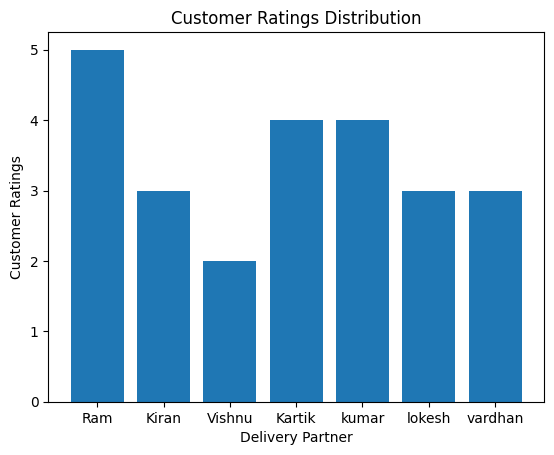

In [29]:
plt.bar(data['Delivery Partner'],data['Customer Ratings'])
plt.xlabel('Delivery Partner')
plt.ylabel('Customer Ratings')
plt.title('Customer Ratings Distribution')
plt.show()

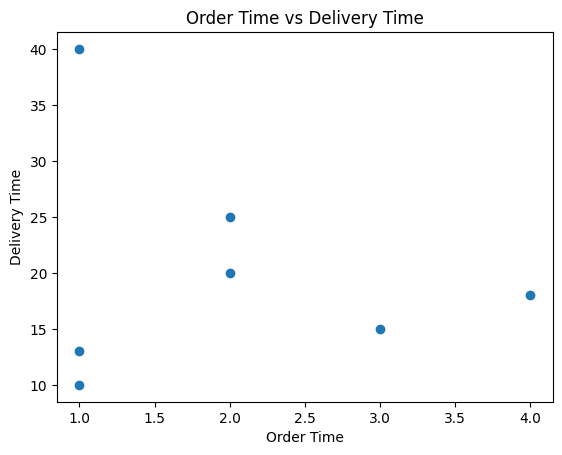

In [30]:
plt.scatter(data['Order Time'],data['Delivery Time'])
plt.xlabel('Order Time')
plt.ylabel('Delivery Time')
plt.title('Order Time vs Delivery Time')
plt.show()

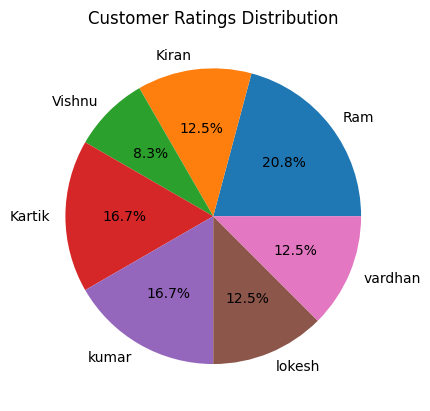

In [31]:
#pie cart based on customer rating and delivery time
plt.pie(data['Customer Ratings'],labels=data['Delivery Partner'],autopct='%1.1f%%')
plt.title('Customer Ratings Distribution')
plt.show()

#2.Online shopping Customer Behavior Analysis

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
customer_data=pd.DataFrame(
    {
        "Customer name":["a","b","c","d","e","f","g","h","i","j"],
        "Product purchases":["Mobile","Hp_Laptop","Kettle","Shirt","MAc_Laptop","book","Mobile","Mobile","Mobile","watch"],
        "Cart abandonment":[["pouch","Screen protector","camera protector"],"keyboardcover","plug box","perfume","mouse","pen","pouch","pouch","shocks","strips"],
        "amount":[30000,75000,1500,999,90000,150,25000,35000,45000,5500],
        "Customer Ratings":[5,5,4,2,5,5,3,2,4,4],
        "Payment method":["UPI","Credit card","cash","Credit card","UPI","cash","UPI","cash","UPI","UPI"]
    }
)
customer_data

,Customer name,Product purchases,Cart abandonment,amount,Customer Ratings,Payment method
0,a,Mobile,"[pouch, Screen protector, camera protector]",30000,5,UPI
1,b,Hp_Laptop,keyboardcover,75000,5,Credit card
2,c,Kettle,plug box,1500,4,cash
3,d,Shirt,perfume,999,2,Credit card
4,e,MAc_Laptop,mouse,90000,5,UPI
5,f,book,pen,150,5,cash
6,g,Mobile,pouch,25000,3,UPI
7,h,Mobile,pouch,35000,2,cash
8,i,Mobile,shocks,45000,4,UPI
9,j,watch,strips,5500,4,UPI


In [18]:
# Most sold product
most_sold_product = customer_data["Product purchases"].mode()[0]
print(f"Most sold product: {most_sold_product}\n")

# High revenue customer
max_amount = customer_data["amount"].max()
high_revenue_customer = customer_data.loc[customer_data["amount"].idxmax(), "Customer name"]

print(f"High revenue customer: {high_revenue_customer} with amount of {max_amount}\n")

# Most preferred payment method
most_preferred_payment = customer_data["Payment method"].mode()[0]
print(f"Most preferred payment method: {most_preferred_payment}")


# Products with poor ratings (rating <= 2)
poor_rated_products = customer_data[customer_data["Customer Ratings"] <= 2][["Product purchases", "Customer Ratings"]].sort_values(by="Customer Ratings")
print("Products with poor ratings:")
print(poor_rated_products)

Most sold product: Mobile

High revenue customer: e with amount of 90000

Most preferred payment method: UPI
Products with poor ratings:
  Product purchases  Customer Ratings
3             Shirt                 2
7            Mobile                 2


In [34]:
print("\n--- Prescriptive Analysis Recommendations ---")


poor_products = customer_data[customer_data['Customer Ratings'] < 3]

print("\n--- Product Improvement Recommendations ---")
for index, row in poor_products.iterrows():
    print(f"Product '{row['Product purchases']}' received a rating of {row['Customer Ratings']}.")
    print("Recommendation: Review product quality, pricing, packaging, and customer feedback.")

high_revenue_customers = customer_data.groupby('Customer name')['amount'].sum().nlargest(3)

print("\n--- Premium Customer Recommendations ---")
for customer in high_revenue_customers.index:
    print(f"Customer {customer}:")
    print("Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.")

most_used_payment_method = customer_data['Payment method'].value_counts().idxmax()

print("\n--- Payment Method Recommendation ---")
print(f"Most customers prefer '{most_used_payment_method}'.")
print("Recommendation: Provide cashback offers and faster checkout options for this payment method.")

top_products = customer_data['Product purchases'].value_counts().nlargest(3)
print("\n--- Inventory Recommendations ---")
for product in top_products.index:
    print(f"Product: {product}")
    print("Recommendation: Maintain sufficient stock and run promotional campaigns.")


--- Prescriptive Analysis Recommendations ---

--- Product Improvement Recommendations ---
Product 'Shirt' received a rating of 2.
Recommendation: Review product quality, pricing, packaging, and customer feedback.
Product 'Mobile' received a rating of 2.
Recommendation: Review product quality, pricing, packaging, and customer feedback.

--- Premium Customer Recommendations ---
Customer e:
Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.
Customer b:
Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.
Customer i:
Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.

--- Payment Method Recommendation ---
Most customers prefer 'UPI'.
Recommendation: Provide cashback offers and faster checkout options for this payment method.

--- Inventory Recommendations ---
Product: Mobile
Recommendation: Maintain sufficient stock and run promotional campaigns.
Product: Hp_Laptop
Recommendation: Maintain

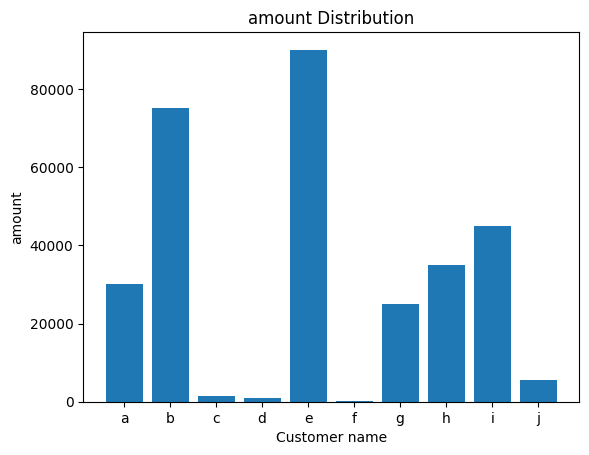

In [37]:
plt.bar(customer_data['Customer name'],customer_data['amount'])
plt.xlabel('Customer name')
plt.ylabel('amount')
plt.title('amount Distribution')
plt.show()

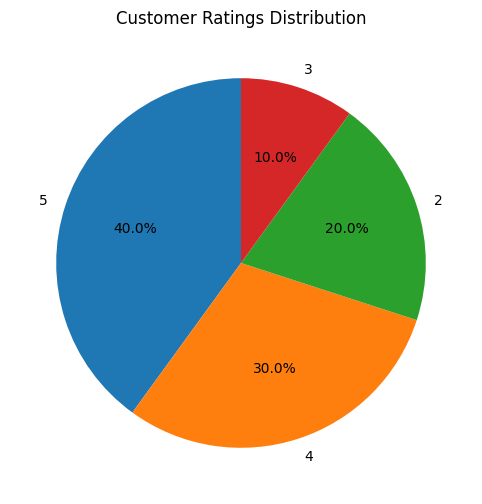

In [36]:
#pie chart for customer ratings distribution
plt.figure(figsize=(8, 6))
plt.pie(customer_data['Customer Ratings'].value_counts(), labels=customer_data['Customer Ratings'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Ratings Distribution")
plt.show()

#Predicting number of ai jobs inrease in next 5 years

Average yearly increase: 54000 jobs

Predicted AI Jobs:
   Year  Predicted_AI_Jobs
0  2026             424000
1  2027             478000
2  2028             532000
3  2029             586000
4  2030             640000

Highest AI jobs expected in: 2030
Predicted jobs: 640000


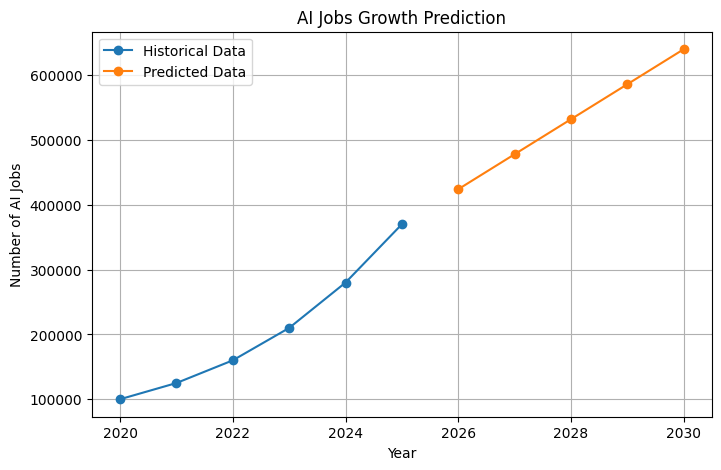

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

ai_jobs_data = pd.DataFrame(
    {
    "Year": [2020, 2021, 2022, 2023, 2024, 2025],
    "AI_Jobs": [100000, 125000, 160000, 210000, 280000, 370000]
  }
)

ai_jobs_data["Increase"] = ai_jobs_data["AI_Jobs"].diff()
avg_increase = ai_jobs_data["Increase"].mean()
print(f"Average yearly increase: {int(avg_increase)} jobs\n")

last_year = ai_jobs_data["Year"].iloc[-1]
last_jobs = ai_jobs_data["AI_Jobs"].iloc[-1]
future_years = []
future_jobs = []
for i in range(1, 6):
    future_year = last_year + i
    predicted_jobs = int(last_jobs + avg_increase * i)
    future_years.append(future_year)
    future_jobs.append(predicted_jobs)
predictions = pd.DataFrame({
    "Year": future_years,
    "Predicted_AI_Jobs": future_jobs
})
print("Predicted AI Jobs:")
print(predictions)
highest_jobs = predictions["Predicted_AI_Jobs"].max()
highest_year = predictions.loc[predictions["Predicted_AI_Jobs"].idxmax(),"Year"]
print(f"\nHighest AI jobs expected in: {highest_year}")
print(f"Predicted jobs: {highest_jobs}")
plt.figure(figsize=(8, 5))
plt.plot(ai_jobs_data["Year"], ai_jobs_data["AI_Jobs"],marker="o", label="Historical Data")
plt.plot(predictions["Year"],predictions["Predicted_AI_Jobs"],marker="o",label="Predicted Data")
plt.title("AI Jobs Growth Prediction")
plt.xlabel("Year")
plt.ylabel("Number of AI Jobs")
plt.legend()
plt.grid(True)
plt.show()

#BANK fraud Transaction Detection






In [57]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.DataFrame(
    {
        "Transaction ID":[1,2,3,4,5,6,7,8,9,10],
        "Transaction amount":[1000,200.073,1500,2700.369,750,2997.68,1200,650.48,8500,1256.036],
        "Location":["a","b","c","d","e","f","g","h","i","j"],
        "time":[22,1,23,2,24,3,22,5,21,6],
        "Account type":["currents","savings","currents","savings","currents","savings","currents","savings","currents","savings"]
    }
)
data

,Transaction ID,Transaction amount,Location,time,Account type
0,1,1000.000,a,22,currents
1,2,200.073,b,1,savings
2,3,1500.000,c,23,currents
3,4,2700.369,d,2,savings
4,5,750.000,e,24,currents
5,6,2997.680,f,3,savings
6,7,1200.000,g,22,currents
7,8,650.480,h,5,savings
8,9,8500.000,i,21,currents
9,10,1256.036,j,6,savings


In [58]:
#amount with paisa
data["Has_Paise"] = np.where(data["Transaction amount"] % 1 != 0,1,0)
print("Unsual Transaction")
print(data[data["Has_Paise"] == 1])

Unsual Transaction
   Transaction ID  Transaction amount Location  time Account type  Has_Paise
1               2             200.073        b     1      savings          1
3               4            2700.369        d     2      savings          1
5               6            2997.680        f     3      savings          1
7               8             650.480        h     5      savings          1
9              10            1256.036        j     6      savings          1


In [62]:
#higher amount
amount_threshold = 500
data["High_Amount"] = np.where(data["Transaction amount"] > amount_threshold,1,0)

#odd timings
data["Odd_Hour"] = np.where((data["time"] >= 22),1,0)
data

data["Risk_Score"]=(
    data["Has_Paise"] * 60
    + data["High_Amount"] * 30
    + data["Odd_Hour"] * 10
)
data["Fraud_Status"] = np.where(data["Risk_Score"] >= 50, "Suspicious", "Normal")
data

,Transaction ID,Transaction amount,Location,time,Account type,Has_Paise,High_Amount,Odd_Hour,Risk_Score,Fraud_Status
0,1,1000.000,a,22,currents,0,1,1,40,Normal
1,2,200.073,b,1,savings,1,0,0,60,Suspicious
2,3,1500.000,c,23,currents,0,1,1,40,Normal
3,4,2700.369,d,2,savings,1,1,0,90,Suspicious
4,5,750.000,e,24,currents,0,1,1,40,Normal
5,6,2997.680,f,3,savings,1,1,0,90,Suspicious
6,7,1200.000,g,22,currents,0,1,1,40,Normal
7,8,650.480,h,5,savings,1,1,0,90,Suspicious
8,9,8500.000,i,21,currents,0,1,0,30,Normal
9,10,1256.036,j,6,savings,1,1,0,90,Suspicious


In [71]:
high_risk = data[data["Fraud_Status"]=="Suspicious"]
print("\nHigh Risk Transactions")
print(high_risk[["Transaction ID","Transaction amount","Account type","Risk_Score"]])



High Risk Transactions
   Transaction ID  Transaction amount Account type  Risk_Score
1               2             200.073      savings          60
3               4            2700.369      savings          90
5               6            2997.680      savings          90
7               8             650.480      savings          90
9              10            1256.036      savings          90


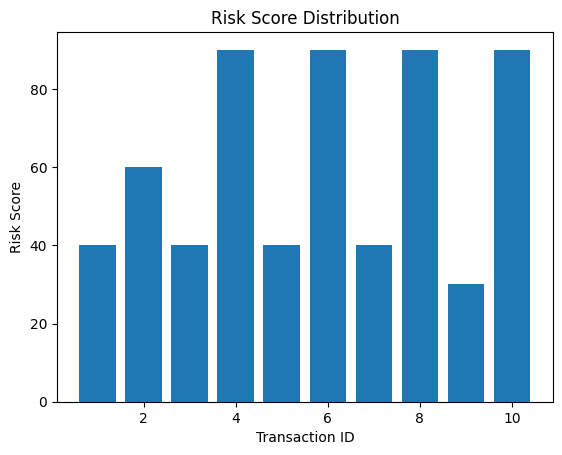

In [72]:
plt.bar(data["Transaction ID"],data["Risk_Score"])
plt.xlabel("Transaction ID")
plt.ylabel("Risk Score")
plt.title("Risk Score Distribution")
plt.show()

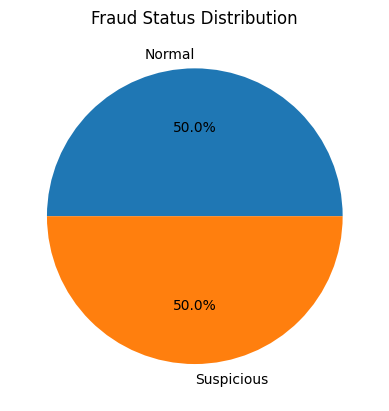

In [73]:
plt.pie(data["Fraud_Status"].value_counts(),labels=data["Fraud_Status"].value_counts().index,autopct="%1.1f%%")
plt.title("Fraud Status Distribution")
plt.show()

Text(0.5, 1.0, 'Transaction amount vs Risk Score')

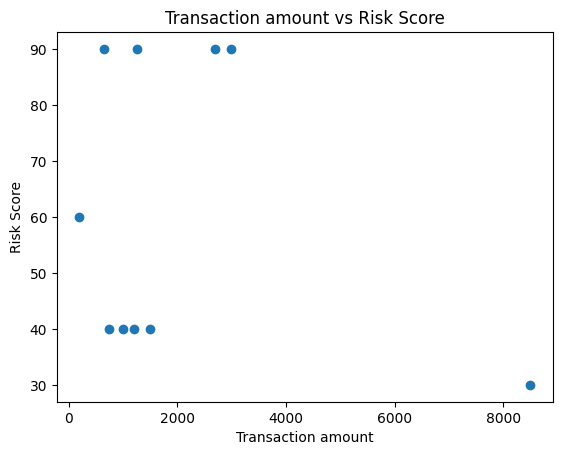

In [74]:
plt.scatter(data["Transaction amount"],data["Risk_Score"])
plt.xlabel("Transaction amount")
plt.ylabel("Risk Score")
plt.title("Transaction amount vs Risk Score")

# Super market Inventory & sales Analysis

In [99]:
import pandas as pd
data=pd.DataFrame(
    {
        "Product ID":[1,2,3,4,5,6,7,8,9,10],
        "Product Name":["Milk","Bread","Rice","Eggs","Apple","Soft Drink","Ice Cream","Cooking Oil","Chocolate","Curd"],
        "Category":["Dairy","Bakery","Grocery","Dairy","Fruits","Beverage","Frozen","Grocery","Snacks","Dairy"],
        "Daily Sales":[120,95,30,110,85,150,140,25,70,100],
        "Current Stock":[40,25,200,0,20,15,10,180,60,100],
        "Expiry Days Remaining":[3,2,180,0,5,90,30,365,120,0],
        "Seasonal Demand":["Medium","Medium","Low","Medium","High","High","High","Low","Medium","Medium"],
        "Price":[30,25,60,6,80,40,50,150,20,35]
    }
)
data

,Product ID,Product Name,Category,Daily Sales,Current Stock,Expiry Days Remaining,Seasonal Demand,Price
0,1,Milk,Dairy,120,40,3,Medium,30
1,2,Bread,Bakery,95,25,2,Medium,25
2,3,Rice,Grocery,30,200,180,Low,60
3,4,Eggs,Dairy,110,0,0,Medium,6
4,5,Apple,Fruits,85,20,5,High,80
5,6,Soft Drink,Beverage,150,15,90,High,40
6,7,Ice Cream,Frozen,140,10,30,High,50
7,8,Cooking Oil,Grocery,25,180,365,Low,150
8,9,Chocolate,Snacks,70,60,120,Medium,20
9,10,Curd,Dairy,100,100,0,Medium,35


In [125]:
#fast moving products
fast_moving_products=data.sort_values(by="Daily Sales",ascending=False).head(3)
print("Fast Moving Products:")
print(fast_moving_products[["Product ID","Product Name","Daily Sales"]])

Fast Moving Products:
   Product ID Product Name  Daily Sales
5           6   Soft Drink          150
6           7    Ice Cream          140
0           1         Milk          120


In [128]:
#solve moving products
moving_products=data.sort_values(by="Current Stock",ascending=False).head(3)
print("\nMoving Products:")
print(moving_products[["Product ID","Product Name","Daily Sales","Current Stock"]])
#


Moving Products:
   Product ID Product Name  Daily Sales  Current Stock
2           3         Rice           30            200
7           8  Cooking Oil           25            180
9          10         Curd          100            100


In [129]:
#nearly expiry product
nearly_expiry_products=data[data["Expiry Days Remaining"]<=7]
print("\nNearly Expiry Products:")
print(nearly_expiry_products[["Product ID","Product Name","Expiry Days Remaining"]])



Nearly Expiry Products:
   Product ID Product Name  Expiry Days Remaining
0           1         Milk                      3
1           2        Bread                      2
3           4         Eggs                      0
4           5        Apple                      5
9          10         Curd                      0


In [130]:
#out-of stock trends
out_of_stock_products=data[data["Current Stock"]==0]
print("\nOut-of-Stock Products:")
print(out_of_stock_products[["Product ID","Product Name","Current Stock"]])



Out-of-Stock Products:
   Product ID Product Name  Current Stock
3           4         Eggs              0
